# During class

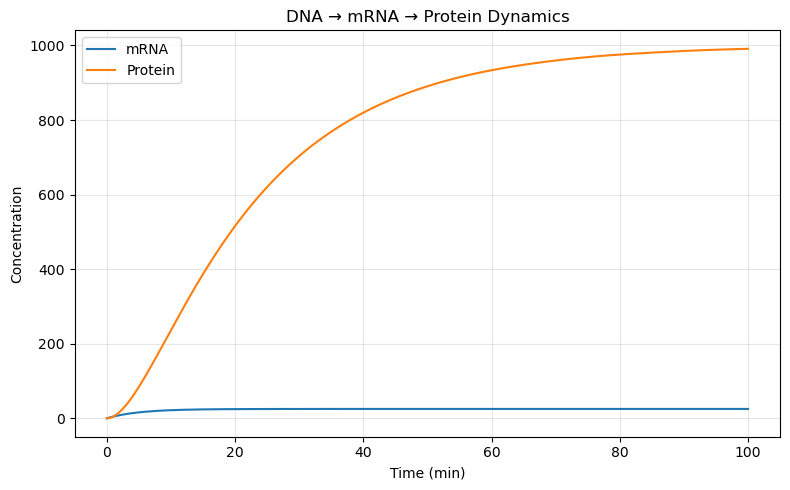

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# 1. 定义基因表达模型
def gene_expression(t, y, k_tx, gamma_m, k_tl, gamma_p):
    
    M = y[0]   # mRNA concentration
    P = y[1]   # Protein concentration

    #tx = transcription
    #tl = translation
    
    # mRNA: production - degradation
    dMdt = k_tx - gamma_m * M
    
    # Protein: production - degradation
    dPdt = k_tl * M - gamma_p * P
    
    return [dMdt, dPdt]


# 2. 设置参数

k_tx = 5.0       # transcription rate: mRNA / min
gamma_m = 0.2    # mRNA degradation rate: / min

k_tl = 2.0       # translation rate: protein per mRNA per min
gamma_p = 0.05   # protein degradation rate: / min


# 3. 初始状态

M0 = 0.0   # initial mRNA
P0 = 0.0   # initial protein


# 4. 模拟时间

time_points = np.linspace(0, 100, 500)


# 5. 求解微分方程

solution = solve_ivp(
    gene_expression,
    t_span=(0, 100),
    y0=[M0, P0],
    args=(k_tx, gamma_m, k_tl, gamma_p),
    t_eval=time_points
)


# 6. 提取结果

time = solution.t
mRNA = solution.y[0]
protein = solution.y[1]


# 7. 画图

plt.figure(figsize=(8, 5))

plt.plot(time, mRNA, label='mRNA')
plt.plot(time, protein, label='Protein')

plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.title('DNA → mRNA → Protein Dynamics')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# Homework

Km = 0.7
Vmax = 0.2


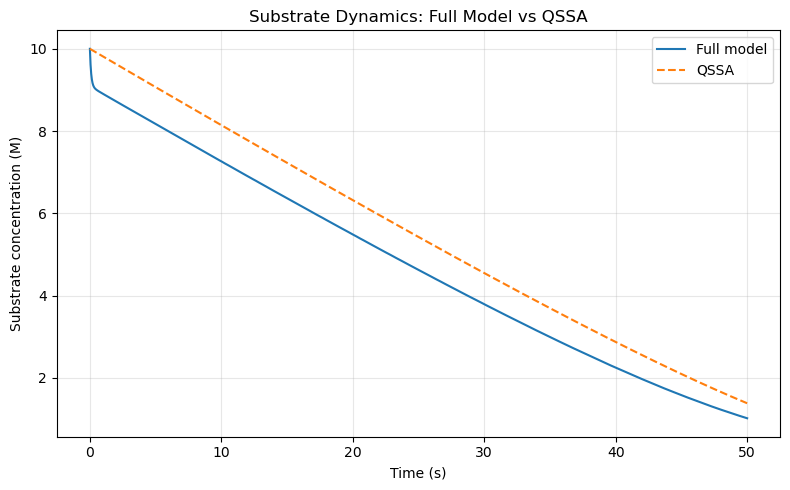

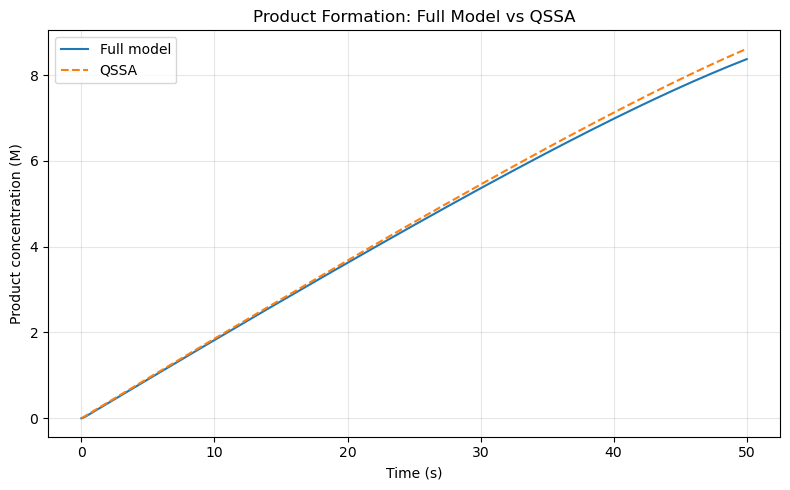

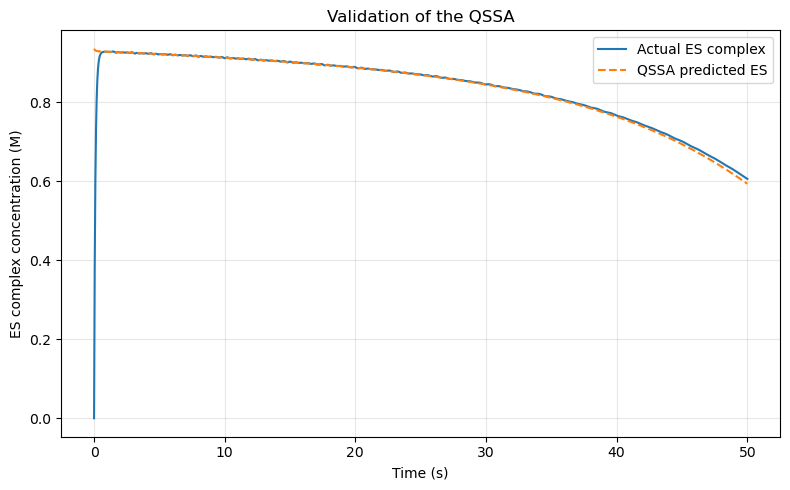

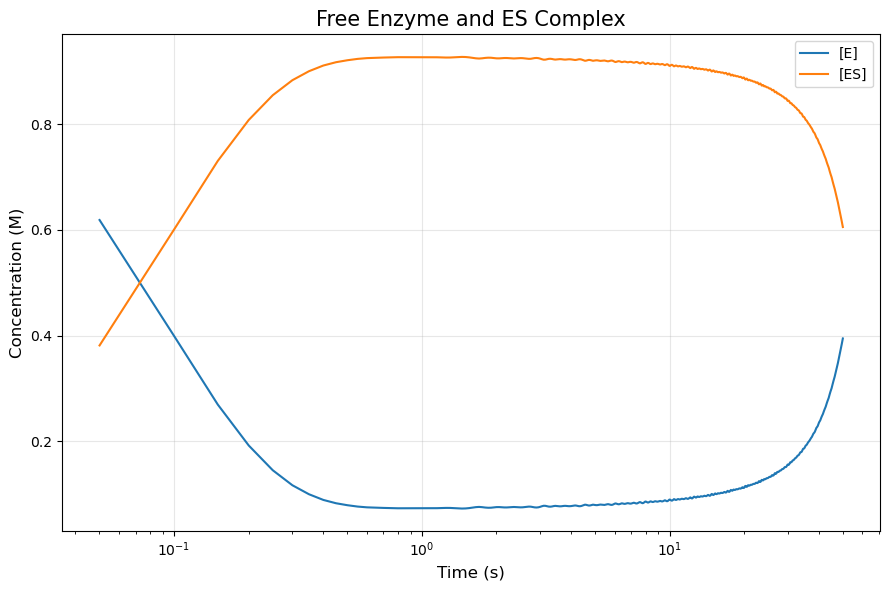

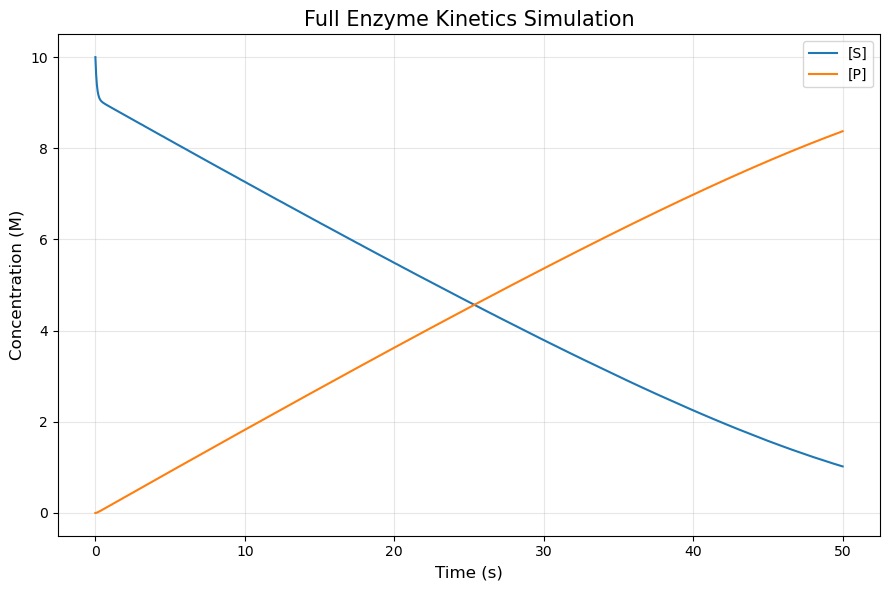

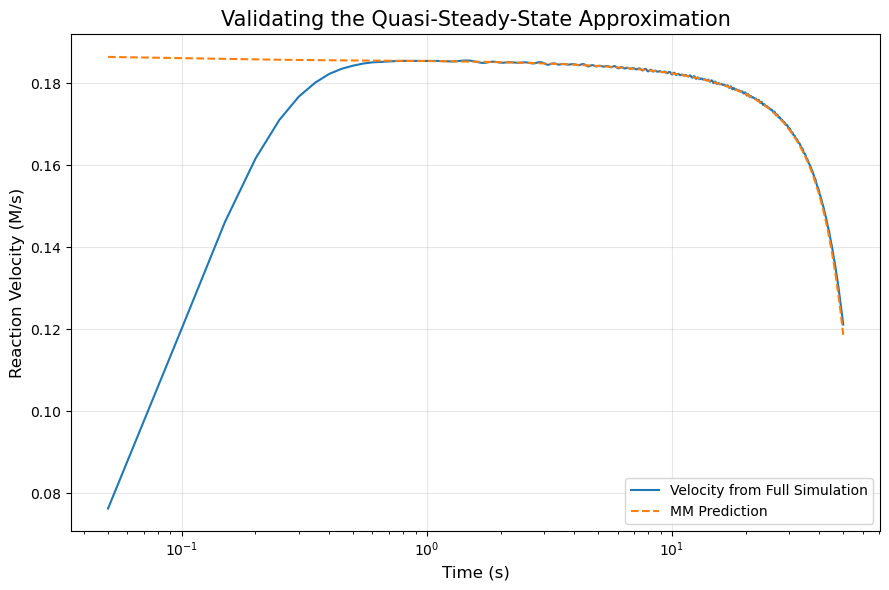

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# =========================================================
# 1. Parameters
# =========================================================

k1 = 1.0          # binding rate constant, M^-1 s^-1
k_minus1 = 0.5    # dissociation rate constant, s^-1
k2 = 0.2          # catalytic rate constant, s^-1

E_total = 1.0     # total enzyme concentration, M
S0 = 10.0         # initial substrate concentration, M


# Michaelis constant
Km = (k_minus1 + k2) / k1

# Maximum reaction velocity
Vmax = k2 * E_total

print("Km =", Km)
print("Vmax =", Vmax)


# =========================================================
# 2. Full enzyme kinetics model
# =========================================================

# y = [S, C, P]
# S = substrate
# C = enzyme-substrate complex, ES
# P = product

def full_model(t, y):

    S = y[0]
    C = y[1]
    P = y[2]

    # Free enzyme
    E = E_total - C

    # Individual reaction rates
    binding = k1 * E * S
    unbinding = k_minus1 * C
    catalysis = k2 * C

    # Differential equations
    dSdt = -binding + unbinding
    dCdt = binding - unbinding - catalysis
    dPdt = catalysis

    return [dSdt, dCdt, dPdt]


# Initial conditions
# initially: S = 10, ES = 0, P = 0
y0 = [S0, 0.0, 0.0]


# Simulation time
t_eval = np.linspace(0, 50, 1000)


# Solve the full model
solution = solve_ivp(
    full_model,
    t_span=(0, 50),
    y0=y0,
    t_eval=t_eval
)


# Extract results
t = solution.t
S = solution.y[0]
C = solution.y[1]
P = solution.y[2]

# Free enzyme concentration
E = E_total - C


# =========================================================
# 3. QSSA model
# =========================================================

# Under QSSA:
#
# C ≈ E_total * S / (Km + S)
#
# v = Vmax * S / (Km + S)


def qssa_model(t, y):

    S = y[0]
    P = y[1]

    # Michaelis-Menten reaction velocity
    v = Vmax * S / (Km + S)

    dSdt = -v
    dPdt = v

    return [dSdt, dPdt]


qssa_solution = solve_ivp(
    qssa_model,
    t_span=(0, 50),
    y0=[S0, 0.0],
    t_eval=t_eval
)

S_qssa = qssa_solution.y[0]
P_qssa = qssa_solution.y[1]


# =========================================================
# 4. Plot 1:
# Full model vs QSSA for substrate
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(t, S, label='Full model')
plt.plot(t, S_qssa, '--', label='QSSA')

plt.xlabel('Time (s)')
plt.ylabel('Substrate concentration (M)')
plt.title('Substrate Dynamics: Full Model vs QSSA')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# =========================================================
# 5. Plot 2:
# Full model vs QSSA for product
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(t, P, label='Full model')
plt.plot(t, P_qssa, '--', label='QSSA')

plt.xlabel('Time (s)')
plt.ylabel('Product concentration (M)')
plt.title('Product Formation: Full Model vs QSSA')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# =========================================================
# 6. Plot 3:
# Actual ES complex vs QSSA-predicted ES
# =========================================================

C_qssa = E_total * S / (Km + S)

plt.figure(figsize=(8, 5))

plt.plot(t, C, label='Actual ES complex')
plt.plot(t, C_qssa, '--', label='QSSA predicted ES')

plt.xlabel('Time (s)')
plt.ylabel('ES complex concentration (M)')
plt.title('Validation of the QSSA')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# =========================================================
# 7. Plot 4:
# Free enzyme E and ES complex
# =========================================================

# Remove t = 0 because log(0) does not exist
mask_log = t > 0

plt.figure(figsize=(9, 6))

plt.plot(t[mask_log], E[mask_log], label='[E]')
plt.plot(t[mask_log], C[mask_log], label='[ES]')

plt.xscale('log')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Concentration (M)', fontsize=12)
plt.title('Free Enzyme and ES Complex', fontsize=15)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# =========================================================
# 8. Plot 5:
# Substrate and Product
# =========================================================

plt.figure(figsize=(9, 6))

plt.plot(t, S, label='[S]')
plt.plot(t, P, label='[P]')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Concentration (M)', fontsize=12)
plt.title('Full Enzyme Kinetics Simulation', fontsize=15)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# =========================================================
# 9. Plot 6:
# Reaction velocity: Full model vs MM/QSSA prediction
# =========================================================

# Full model velocity
v_full = k2 * C

# Michaelis-Menten prediction
v_mm = Vmax * S / (Km + S)

plt.figure(figsize=(9, 6))

plt.plot(
    t[mask_log],
    v_full[mask_log],
    label='Velocity from Full Simulation'
)

plt.plot(
    t[mask_log],
    v_mm[mask_log],
    '--',
    label='MM Prediction'
)

plt.xscale('log')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Reaction Velocity (M/s)', fontsize=12)
plt.title(
    'Validating the Quasi-Steady-State Approximation',
    fontsize=15
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()